In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, ttest_ind

class TaxiTrips:
    def __init__(self, df=None, filename=None):
        """
        Initialize with either a DataFrame or a CSV file.
        """
        if filename:
            self.df = pd.read_csv(filename, dtype={"store_and_fwd_flag": str}, low_memory=False)
        elif df is not None:
            self.df = df
        else:
            raise ValueError("Provide either a DataFrame or a filename.")

        
        self.df['tpep_pickup_datetime'] = pd.to_datetime(
        self.df['tpep_pickup_datetime'], 
        format='%Y-%m-%d %H:%M:%S', 
        errors='coerce')
        self.df['tpep_dropoff_datetime'] = pd.to_datetime(
        self.df['tpep_dropoff_datetime'], 
        format='%Y-%m-%d %H:%M:%S', 
        errors='coerce')


   
    def head(self, n=5):
        return self.df.head(n)

    def tail(self, n=5):
        return self.df.tail(n)

    def shape(self):
        return self.df.shape

    def columns(self):
        return self.df.columns.tolist()

    def info(self):
        return self.df.dtypes

    def describe(self):
        return self.df.describe(include='all')

    def unique_counts(self):
        return self.df.nunique()

    def categorical_summary(self):
        return self.df.describe(include='object')

    def null_counts(self):
        return self.df.isnull().sum()

    def null_percentage(self):
        return (self.df.isnull().mean() * 100).round(2)

    def duplicates(self):
        return self.df[self.df.duplicated()]

    
    def fillna_with_mode(self, col):
        if col in self.df.columns and self.df[col].isnull().sum() > 0:
            mode_val = self.df[col].mode()[0]
            self.df[col] = self.df[col].fillna(mode_val)

    def drop_nulls(self):
        self.df.dropna(inplace=True)

    def drop_duplicates(self):
        self.df.drop_duplicates(inplace=True)

    def drop_column(self, col):
        if col in self.df.columns:
            self.df.drop(columns=[col], inplace=True)

    def convert_dtype(self, col, dtype):
        if col in self.df.columns:
            self.df[col] = self.df[col].astype(dtype)

    
    def detect_outliers(self, column):
        col = pd.to_numeric(self.df[column], errors='coerce').dropna()
        Q1, Q3 = col.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = self.df[(self.df[column] < lower) | (self.df[column] > upper)]
        return outliers[column].tolist()

    
    def plot_distribution(self, column):
        plt.figure(figsize=(8, 4))
        sns.histplot(self.df[column].dropna(), kde=True)
        plt.title(f"Distribution of {column}")
        plt.show()

    def plot_count(self, column):
        plt.figure(figsize=(8, 4))
        sns.countplot(x=self.df[column])
        plt.title(f"Count Plot of {column}")
        plt.xticks(rotation=45)
        plt.show()

    def box_plot(self, column):
        plt.figure(figsize=(6, 4))
        sns.boxplot(y=self.df[column], color='skyblue')
        plt.title(f'Boxplot of {column}')
        plt.show()

    def plot_pie(self, column):
        self.df[column].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6, 6))
        plt.title(f"Pie Chart of {column}")
        plt.ylabel('')
        plt.show()

    def plot_bar(self, column):
        self.df[column].value_counts().plot.bar(figsize=(8, 4))
        plt.title(f"Bar Chart of {column}")
        plt.xticks(rotation=45)
        plt.show()

    def plot_scatter(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=self.df[x], y=self.df[y])
        plt.title(f"Scatter Plot: {x} vs {y}")
        plt.show()

    def plot_line(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=self.df[x], y=self.df[y])
        plt.title(f"Line Plot: {x} vs {y}")
        plt.show()

    def correlation_heatmap(self):
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.df.corr(numeric_only=True), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        plt.show()

    
    def chi_square(self, col1, col2):
        table = pd.crosstab(self.df[col1], self.df[col2])
        _, p, _, _ = chi2_contingency(table)
        return p

    def continuous_correlations(self):
        corr_matrix = self.df.select_dtypes(include=['int64', 'float64']).corr()
        correlated_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
                corr_value = corr_matrix.iloc[i, j]
                correlated_pairs.append((col1, col2, corr_value))
        return sorted(correlated_pairs, key=lambda x: abs(x[2]), reverse=True)

    def anova_test(self, target):
        results = []
        if target not in self.df.columns:
            return pd.DataFrame()
        categorical_cols = self.df.select_dtypes(include='object').columns
        for cat in categorical_cols:
            if self.df[cat].nunique() > 1:
                groups = [group[target].dropna().values
                          for _, group in self.df.groupby(cat) if len(group[target].dropna()) > 1]
                if len(groups) > 1:
                    stat, p = f_oneway(*groups)
                    results.append({'Feature': cat, 'ANOVA_p_value': round(p, 4)})
        return pd.DataFrame(results)

    def t_test(self, cat_col, target):
        groups = self.df[cat_col].dropna().unique()
        if len(groups) != 2:
            raise ValueError("T-test is only applicable for binary categorical variables")
        group1 = self.df[self.df[cat_col] == groups[0]][target].dropna()
        group2 = self.df[self.df[cat_col] == groups[1]][target].dropna()
        _, p = ttest_ind(group1, group2)
        return p

    
    def save_to_csv(self, filename):
        self.df.to_csv(filename, index=False)


In [2]:
taxi_df = TaxiTrips(filename="Taxi_Trip_Data.csv")

In [40]:
taxi_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,NaT,NaT,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,NaT,NaT,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,NaT,NaT,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,NaT,NaT,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,NaT,NaT,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [41]:
taxi_df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
6499995,2.0,NaT,NaT,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,NaT,NaT,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,NaT,NaT,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,NaT,NaT,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5
6499999,2.0,NaT,NaT,4.0,1.89,1.0,N,142,236,1.0,9.5,0.0,0.5,2.56,0.00,0.3,15.36,2.5


In [42]:
taxi_df.columns()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge']

In [43]:
taxi_df.info()

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

In [44]:
taxi_df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,6.420771e+06,0,0,6.420771e+06,6.500000e+06,6.420771e+06,6420771,6.500000e+06,6.500000e+06,6.420771e+06,6.500000e+06,6.500000e+06,6.500000e+06,6.500000e+06,6.500000e+06,6.500000e+06,6.500000e+06,6.500000e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,6351828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.669844e+00,NaT,NaT,1.515719e+00,2.946476e+00,1.059781e+00,NaN,1.645881e+02,1.625559e+02,1.270356e+00,1.273255e+01,1.110699e+00,4.923319e-01,2.186040e+00,3.500850e-01,2.979841e-01,1.869325e+01,2.272097e+00
min,1.000000e+00,NaT,NaT,0.000000e+00,-3.062000e+01,1.000000e+00,NaN,1.000000e+00,1.000000e+00,1.000000e+00,-1.238000e+03,-2.700000e+01,-5.000000e-01,-9.100000e+01,-3.574000e+01,-3.000000e-01,-1.242300e+03,-2.500000e+00
25%,1.000000e+00,NaT,NaT,1.000000e+00,9.600000e-01,1.000000e+00,NaN,1.320000e+02,1.130000e+02,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01,2.500000e+00
50%,2.000000e+00,NaT,NaT,1.000000e+00,1.600000e+00,1.000000e+00,NaN,1.620000e+02,1.620000e+02,1.000000e+00,9.000000e+00,5.000000e-01,5.000000e-01,1.950000e+00,0.000000e+00,3.000000e-01,1.430000e+01,2.500000e+00
75%,2.000000e+00,NaT,NaT,2.000000e+00,2.950000e+00,1.000000e+00,NaN,2.340000e+02,2.340000e+02,2.000000e+00,1.400000e+01,2.500000e+00,5.000000e-01,2.860000e+00,0.000000e+00,3.000000e-01,1.980000e+01,2.500000e+00
max,2.000000e+00,NaT,NaT,9.000000e+00,2.102401e+05,9.900000e+01,NaN,2.650000e+02,2.650000e+02,5.000000e+00,4.265000e+03,1.130100e+02,3.080000e+01,1.100000e+03,9.105000e+02,3.000000e-01,4.268300e+03,2.750000e+00


In [45]:
taxi_df.unique_counts()

VendorID                     2
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count             10
trip_distance             5626
RatecodeID                   7
store_and_fwd_flag           2
PULocationID               261
DOLocationID               262
payment_type                 5
fare_amount               5931
extra                       47
mta_tax                     11
tip_amount                3644
tolls_amount              1041
improvement_surcharge        3
total_amount             12609
congestion_surcharge         8
dtype: int64

In [46]:
taxi_df.categorical_summary()

,store_and_fwd_flag
count,6420771
unique,2
top,N
freq,6351828


In [47]:
taxi_df.null_counts()

VendorID                   79229
tpep_pickup_datetime     6500000
tpep_dropoff_datetime    6500000
passenger_count            79229
trip_distance                  0
RatecodeID                 79229
store_and_fwd_flag         79229
PULocationID                   0
DOLocationID                   0
payment_type               79229
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge           0
dtype: int64

In [48]:
taxi_df.null_percentage()

VendorID                   1.22
tpep_pickup_datetime     100.00
tpep_dropoff_datetime    100.00
passenger_count            1.22
trip_distance              0.00
RatecodeID                 1.22
store_and_fwd_flag         1.22
PULocationID               0.00
DOLocationID               0.00
payment_type               1.22
fare_amount                0.00
extra                      0.00
mta_tax                    0.00
tip_amount                 0.00
tolls_amount               0.00
improvement_surcharge      0.00
total_amount               0.00
congestion_surcharge       0.00
dtype: float64

In [49]:
taxi_df.duplicates()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
1911,2.0,NaT,NaT,4.0,0.00,5.0,N,265,265,2.0,70.0,0.0,0.0,0.00,0.00,0.3,70.30,0.0
2954,1.0,NaT,NaT,1.0,0.90,1.0,N,237,263,1.0,5.5,3.0,0.5,1.85,0.00,0.3,11.15,2.5
3510,2.0,NaT,NaT,1.0,0.00,1.0,N,193,193,2.0,2.5,0.0,0.5,0.00,0.00,0.3,3.30,0.0
4648,1.0,NaT,NaT,1.0,0.00,1.0,N,145,145,2.0,2.5,0.0,0.5,0.00,0.00,0.3,3.30,0.0
4694,2.0,NaT,NaT,1.0,0.00,1.0,N,193,193,2.0,2.5,0.0,0.5,0.00,0.00,0.3,3.30,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499984,2.0,NaT,NaT,1.0,1.49,1.0,N,237,236,1.0,8.0,0.0,0.5,1.00,0.00,0.3,12.30,2.5
6499990,2.0,NaT,NaT,1.0,1.42,1.0,N,162,186,2.0,9.5,0.0,0.5,0.00,0.00,0.3,12.80,2.5
6499992,2.0,NaT,NaT,1.0,1.18,1.0,N,107,170,1.0,6.5,0.0,0.5,1.96,0.00,0.3,11.76,2.5
6499994,2.0,NaT,NaT,1.0,1.56,1.0,N,236,43,1.0,8.0,0.0,0.5,2.26,0.00,0.3,13.56,2.5


In [50]:
taxi_df.fillna_with_mode("store_and_fwd_flag")

In [51]:
taxi_df.drop_duplicates() 

In [52]:
taxi_df.detect_outliers("trip_distance")

[7.76,
 8.45,
 8.7,
 7.1,
 14.52,
 6.7,
 8.0,
 9.9,
 12.92,
 7.76,
 7.21,
 8.6,
 13.7,
 8.2,
 6.6,
 6.72,
 11.85,
 15.69,
 10.05,
 6.7,
 18.2,
 7.03,
 13.3,
 9.84,
 7.53,
 9.93,
 10.91,
 7.05,
 9.28,
 13.6,
 18.39,
 11.4,
 14.9,
 19.19,
 23.47,
 10.1,
 8.92,
 6.57,
 7.25,
 7.1,
 11.8,
 7.7,
 11.12,
 7.0,
 9.88,
 8.88,
 6.84,
 6.77,
 7.37,
 7.09,
 11.05,
 6.54,
 17.2,
 6.56,
 8.2,
 22.8,
 17.1,
 8.46,
 11.35,
 7.7,
 11.59,
 7.0,
 7.85,
 12.83,
 37.61,
 13.21,
 8.13,
 8.46,
 8.32,
 8.99,
 7.6,
 6.83,
 7.88,
 10.9,
 7.5,
 14.07,
 8.0,
 9.7,
 8.25,
 13.94,
 7.09,
 11.42,
 6.91,
 8.12,
 7.48,
 16.15,
 7.07,
 7.9,
 11.7,
 9.35,
 19.29,
 20.32,
 11.1,
 12.87,
 8.47,
 10.68,
 6.87,
 13.82,
 19.1,
 12.17,
 7.99,
 7.95,
 29.4,
 7.53,
 7.73,
 6.71,
 6.75,
 11.1,
 6.56,
 6.97,
 7.36,
 9.2,
 7.52,
 12.54,
 7.22,
 10.45,
 9.66,
 7.54,
 6.57,
 7.16,
 6.59,
 7.2,
 6.79,
 9.11,
 7.77,
 7.08,
 7.0,
 12.2,
 8.5,
 15.56,
 8.6,
 9.14,
 7.45,
 8.05,
 12.0,
 14.93,
 15.0,
 9.4,
 19.39,
 25.92,
 8.7,
 7.28,
 

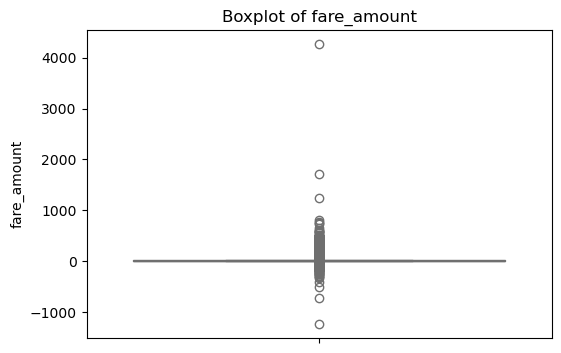

In [13]:
taxi_df.box_plot("fare_amount")

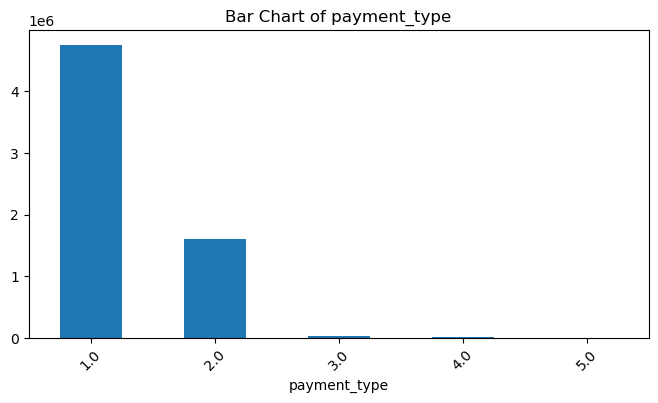

In [11]:
taxi_df.plot_bar("payment_type")

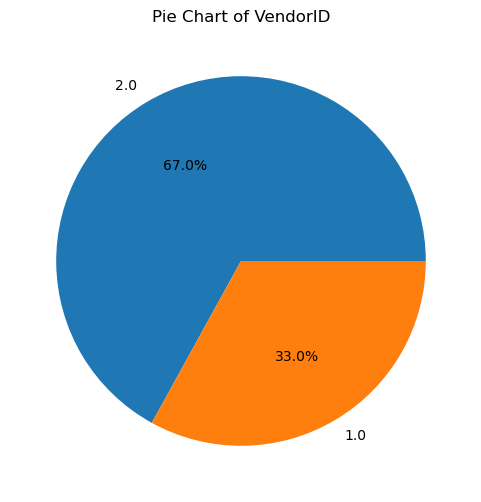

In [10]:
taxi_df.plot_pie("VendorID")

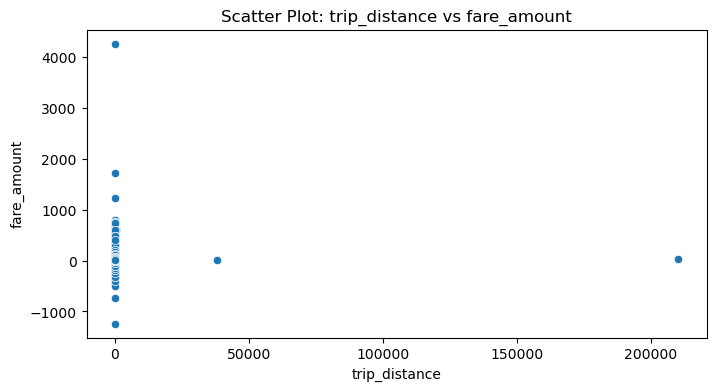

In [9]:
taxi_df.plot_scatter("trip_distance", "fare_amount")

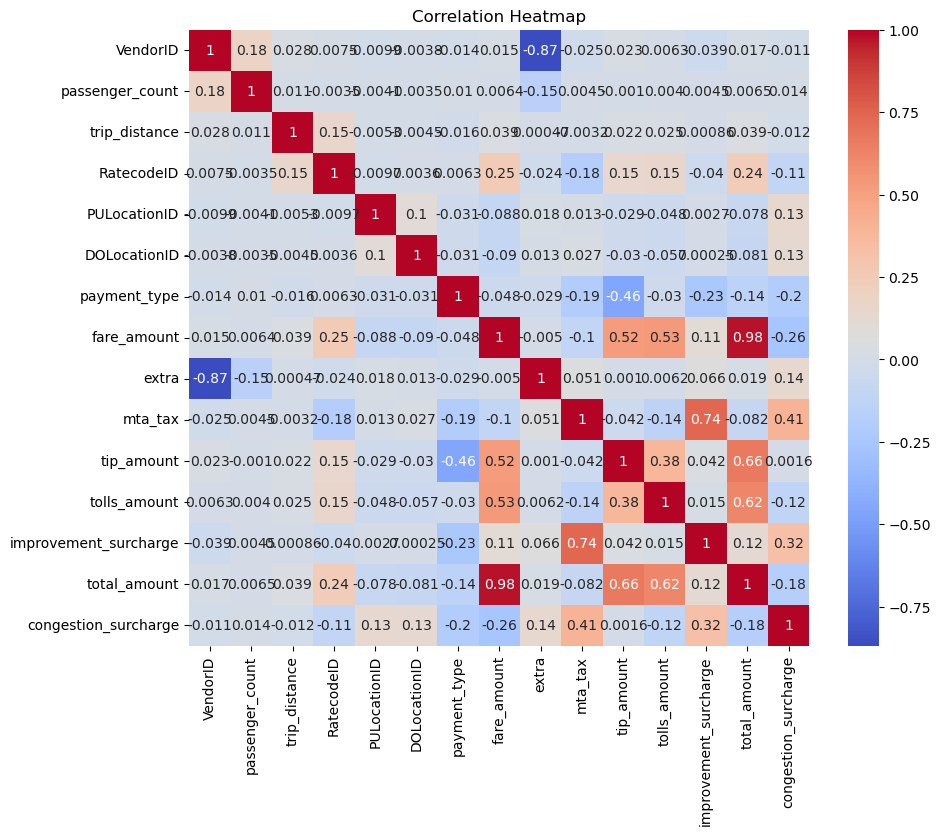

In [8]:
taxi_df.correlation_heatmap()

In [6]:
taxi_df.chi_square("VendorID", "payment_type")

0.0

In [7]:
taxi_df.continuous_correlations()

[('fare_amount', 'total_amount', 0.976599657113077),
 ('VendorID', 'extra', -0.868420749799659),
 ('mta_tax', 'improvement_surcharge', 0.7396417682185126),
 ('tip_amount', 'total_amount', 0.6644182505319377),
 ('tolls_amount', 'total_amount', 0.6201385328703081),
 ('fare_amount', 'tolls_amount', 0.5258849307536494),
 ('fare_amount', 'tip_amount', 0.523141493463216),
 ('payment_type', 'tip_amount', -0.4560580594719497),
 ('mta_tax', 'congestion_surcharge', 0.4071637168766284),
 ('tip_amount', 'tolls_amount', 0.37975631501701596),
 ('improvement_surcharge', 'congestion_surcharge', 0.32166244945897154),
 ('fare_amount', 'congestion_surcharge', -0.2569199223900228),
 ('RatecodeID', 'fare_amount', 0.25061401609077366),
 ('RatecodeID', 'total_amount', 0.24439670393487214),
 ('payment_type', 'improvement_surcharge', -0.23410029556343476),
 ('payment_type', 'congestion_surcharge', -0.20238348730027936),
 ('payment_type', 'mta_tax', -0.191273012073816),
 ('RatecodeID', 'mta_tax', -0.18276424987

In [4]:
taxi_df.anova_test("fare_amount")

,Feature,ANOVA_p_value
0,store_and_fwd_flag,0.4995


In [3]:
taxi_df.t_test("store_and_fwd_flag", "trip_distance")

3.0291246139328917e-13